# Ejercicio 2

    Utilice para entrenamiento y prueba los conjuntos de datos concent-
trn.csv y concent tst.csv, que consisten en dos clases distribuidas en forma
conc ́entrica como muestra la Figura 1. Determine la estructura de una red
de tipo perceptr ́on multicapa que resulte m ́as apropiada para resolver este
problema. Represente gr ́aficamente, con diferentes colores, el resultado de la
clasificaci ́on realizada por el perceptr ́on multicapa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *

(1499, 2)
(1499,)


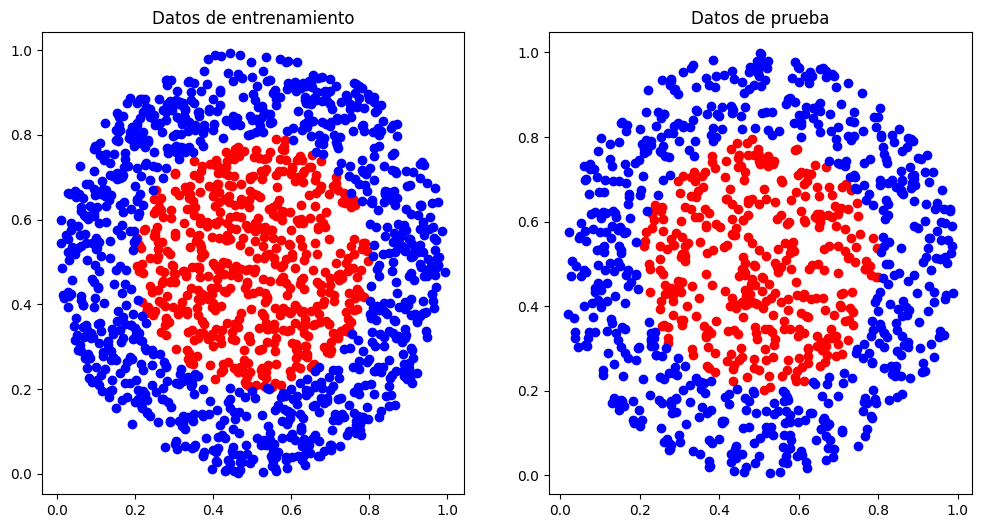

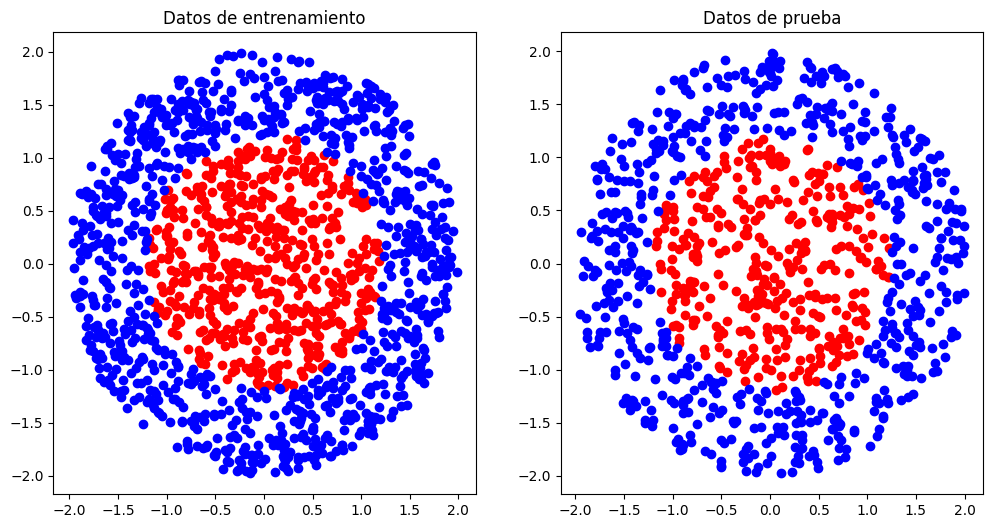

In [19]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'concent_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'concent_tst.csv'))

y_train_flatted = y_train.flatten()
y_test_flatted = y_test.flatten()
print(X_train.shape)
print(y_train_flatted.shape)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Datos de entrenamiento")
plt.scatter(X_train[y_train_flatted == -1][:, 0], X_train[y_train_flatted == -1][:, 1], color='red')
plt.scatter(X_train[y_train_flatted == 1][:, 0], X_train[y_train_flatted == 1][:, 1], color='blue')

plt.subplot(1,2,2)
plt.title("Datos de prueba")
plt.scatter(X_test[y_test_flatted == -1][:, 0], X_test[y_test_flatted == -1][:, 1], color='red')
plt.scatter(X_test[y_test_flatted == 1][:, 0], X_test[y_test_flatted == 1][:, 1], color='blue')
plt.show()

X_train_norm = (X_train - np.mean(X_train, axis=0))/np.std(X_train, axis=0)
X_test_norm = (X_test - np.mean(X_test, axis=0))/np.std(X_test, axis=0)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Datos de entrenamiento")
plt.scatter(X_train_norm[y_train_flatted == -1][:, 0], X_train_norm[y_train_flatted == -1][:, 1], color='red')
plt.scatter(X_train_norm[y_train_flatted == 1][:, 0], X_train_norm[y_train_flatted == 1][:, 1], color='blue')

plt.subplot(1,2,2)
plt.title("Datos de prueba")
plt.scatter(X_test_norm[y_test_flatted == -1][:, 0], X_test_norm[y_test_flatted == -1][:, 1], color='red')
plt.scatter(X_test_norm[y_test_flatted == 1][:, 0], X_test_norm[y_test_flatted == 1][:, 1], color='blue')
plt.show()

In [20]:
model = neural_network(
    layers_config = [(5, 'symmetry sigmoid'), (5, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input = X_train_norm.shape[1],
    max_epoch=100,
    learning_rate=0.01,
    error_threshold=1e-3)

model.fit(X_train_norm, y_train)

y_pred = model.transform(X_test_norm)

print(model.score(X_test_norm, y_test))

Época: 0 - Errorcito: 1404.6676800458063
Época: 1 - Errorcito: 1396.9124147610842
Época: 2 - Errorcito: 1391.1820778059644
Época: 3 - Errorcito: 1385.7795712998254
Época: 4 - Errorcito: 1380.1532808030215
Época: 5 - Errorcito: 1373.9155697102844
Época: 6 - Errorcito: 1366.6419369194423
Época: 7 - Errorcito: 1357.76744868072
Época: 8 - Errorcito: 1346.495829445582
Época: 9 - Errorcito: 1331.7262736252899
Época: 10 - Errorcito: 1312.036009599134
Época: 11 - Errorcito: 1285.8003404832589
Época: 12 - Errorcito: 1251.628600227455
Época: 13 - Errorcito: 1209.4097209515915
Época: 14 - Errorcito: 1161.8991651563592
Época: 15 - Errorcito: 1115.2506489344712
Época: 16 - Errorcito: 1076.2907111945221
Época: 17 - Errorcito: 1048.1059675634992
Época: 18 - Errorcito: 1028.821960889974
Época: 19 - Errorcito: 1013.9089858259276
Época: 20 - Errorcito: 998.1618247010113
Época: 21 - Errorcito: 975.6185367945388
Época: 22 - Errorcito: 938.2216731899705
Época: 23 - Errorcito: 876.2470445225446
Época: 24 - 

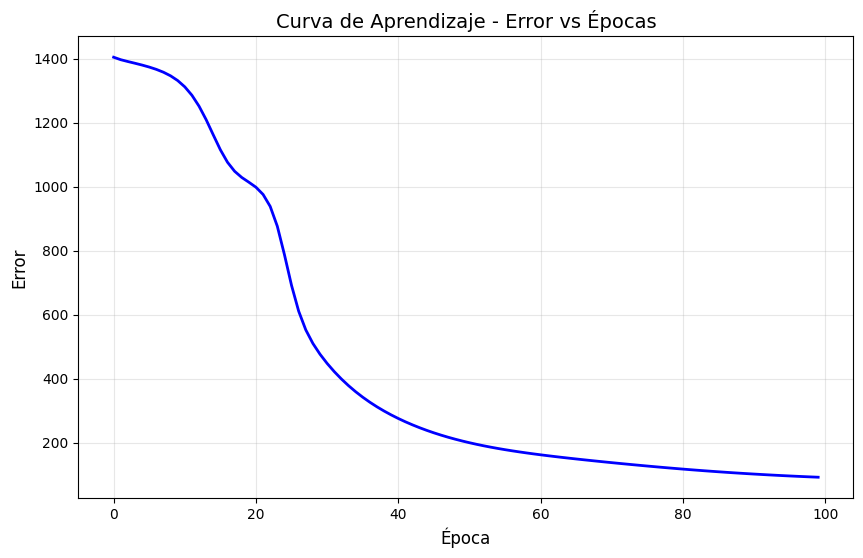

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
def graficar_malla(model, plt):
    x_min, x_max = -2.5, 2.5
    y_min, y_max = -2.5, 2.5

    resolucion = 0.05 #delta x y delta y para hacer la maya

    xx=np.arange(x_min, x_max, resolucion)
    yy=np.arange(y_min, y_max, resolucion)

    #creamos la malla 2d
    X_malla, Y_malla = np.meshgrid(xx, yy)

    #para cada punto de la malla predecimos su clase

    puntos_aplanados = np.c_[X_malla.ravel(), Y_malla.ravel()] #los aplana para recorrerlos

    predicciones = []
    for punto in puntos_aplanados:
        punto_fila = punto.reshape(1,-1) #nuestra red espera una fila
        salida = model.transform(punto_fila)
        predicciones.append(salida.flatten()[0]) #retorna array nuestra salida

    #convertimos a una malla
    Z = np.array(predicciones).reshape(X_malla.shape)

    cont = plt.contourf(X_malla, Y_malla, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(cont)
    for i in range(len(X_test_norm)):
        if y_test[i] == 1:
            plt.scatter(X_test_norm[i, 0], X_test_norm[i, 1], color='blue', s=100, edgecolors='black')
        else:
            plt.scatter(X_test_norm[i, 0], X_test_norm[i, 1], color='red', s=100, edgecolors='black')




In [ ]:
combinaciones = [
    1, 2, 3, 4,
]
plt.figure(figsize=(24,24))

for i in range(len(combinaciones)):
    plt.subplot(3,3,i+1)
    model = neural_network(
        layers_config = [
            (combinaciones[i], 'symmetry sigmoid'),
            (1, 'symmetry sigmoid')
        ],
        size_input = X_train_norm.shape[1],
        max_epoch=100,
        learning_rate=0.01,
        error_threshold=1e-3)

    plt.title(f"Capa {combinaciones[i][0]}-1")
    model.fit(X_train_norm, y_train)
    graficar_malla(model, plt)

Época: 0 - Errorcito: 1391.4926205027443
Época: 1 - Errorcito: 1391.277536588744
Época: 2 - Errorcito: 1391.0168245368068
Época: 3 - Errorcito: 1390.7302890757587
Época: 4 - Errorcito: 1390.4132946461734
Época: 5 - Errorcito: 1390.0595181191966
Época: 6 - Errorcito: 1389.660883819818
Época: 7 - Errorcito: 1389.2069969731688
Época: 8 - Errorcito: 1388.6843821455905
Época: 9 - Errorcito: 1388.0754713429835
Época: 10 - Errorcito: 1387.3572664248672
Época: 11 - Errorcito: 1386.499585387639
Época: 12 - Errorcito: 1385.4627889639241
Época: 13 - Errorcito: 1384.1948736295878
Época: 14 - Errorcito: 1382.6278033642761
Época: 15 - Errorcito: 1380.6729098750689
Época: 16 - Errorcito: 1378.2150561994576
Época: 17 - Errorcito: 1375.1049190316776
Época: 18 - Errorcito: 1371.1480637975808
Época: 19 - Errorcito: 1366.0883947482157
Época: 20 - Errorcito: 1359.5822968375141
Época: 21 - Errorcito: 1351.1597355231916
Época: 22 - Errorcito: 1340.1742990846788
Época: 23 - Errorcito: 1325.7629318472486
Época

KeyboardInterrupt: 